In [ ]:
# Heart Disease Prediction with PyTorch Neural Network
# Biomedical Data Science Capstone Project
# FULL PIPELINE - ARIHANT SINGH
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, accuracy_score, f1_score, precision_score, recall_score)
import scipy.stats as stats

# Random seed as done in class for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
# Load the Cleveland Heart Disease Dataset
print("Loading Heart Dataset")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# read column names and print shape of the data, set null values to ?
df = pd.read_csv(url, names=column_names, na_values='?')
num_samples = df.shape[0]
num_features = df.shape[1]
print("We have", num_samples, "samples and", num_features, "features in the dataset")


# df.info() gives dataset information for each column, which will be needed for cleaning
print("Dataset Overview")
df.info()

Loading Heart Dataset
We have 303 samples and 14 features in the dataset
Dataset Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [ ]:
# Create a copy
heart_df = df.copy()
missing = heart_df.isnull()
missing_count = missing.sum()

# Print number of missing values
print("Number of missing values are", missing_count)

# Drop missing values
heart_df = heart_df.dropna()
print("Heart dataset is of length after cleaning: ", str(len(heart_df)))

# Convert target to binary (0: no disease, 1: disease)
heart_df['target'] = (heart_df['target'] > 0).astype(int)

# Feature descriptions for clinical context
feature_descriptions = {
    'age': 'Age in years',
    'sex': 'Sex (1 = male; 0 = female)',
    'cp': 'Chest pain type (0: typical angina, 1: atypical angina, 2: non-anginal pain, 3: asymptomatic)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol': 'Serum cholesterol (mg/dl)',
    'fbs': 'Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)',
    'restecg': 'Resting electrocardiographic results',
    'thalach': 'Maximum heart rate achieved',
    'exang': 'Exercise induced angina (chest/heart pain) (1 = yes; 0 = no)',
    'oldpeak': 'ST depression induced by exercise relative to rest',
    'slope': 'Slope of the peak exercise ST segment',
    'ca': 'Number of major vessels (0-3) colored by fluoroscopy; Essentially, higher numbers usually indicate more extensive coronary artery involvement, which can suggest a higher risk of heart disease.',
    'thal': 'Thalassemia (3 = normal; 6 = fixed defect; 7 = reversible defect)',
    'target': 'Heart disease (0 = no, 1 = yes)'
}
from pprint import pprint
# nice printing format for the dictionary (clinical context)
pprint(feature_descriptions)


Number of missing values are age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
Heart dataset is of length after cleaning:  297
{'age': 'Age in years',
 'ca': 'Number of major vessels (0-3) colored by fluoroscopy; Essentially, '
       'higher numbers usually indicate more extensive coronary artery '
       'involvement, which can suggest a higher risk of heart disease.',
 'chol': 'Serum cholesterol (mg/dl)',
 'cp': 'Chest pain type (0: typical angina, 1: atypical angina, 2: non-anginal '
       'pain, 3: asymptomatic)',
 'exang': 'Exercise induced angina (chest/heart pain) (1 = yes; 0 = no)',
 'fbs': 'Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)',
 'oldpeak': 'ST depression induced by exercise relative to rest',
 'restecg': 'Resting electrocardiographic results',
 'sex': 'Sex (1 = male; 0 = female)',
 'slope': 'Slope of 

Maximum age of a patient in the dataset is 78.0
Index(['age_group', 'target'], dtype='object')


/tmp/ipython-input-3278292910.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_prop = heart_df2.groupby('age_group')['target'].mean().reset_index()


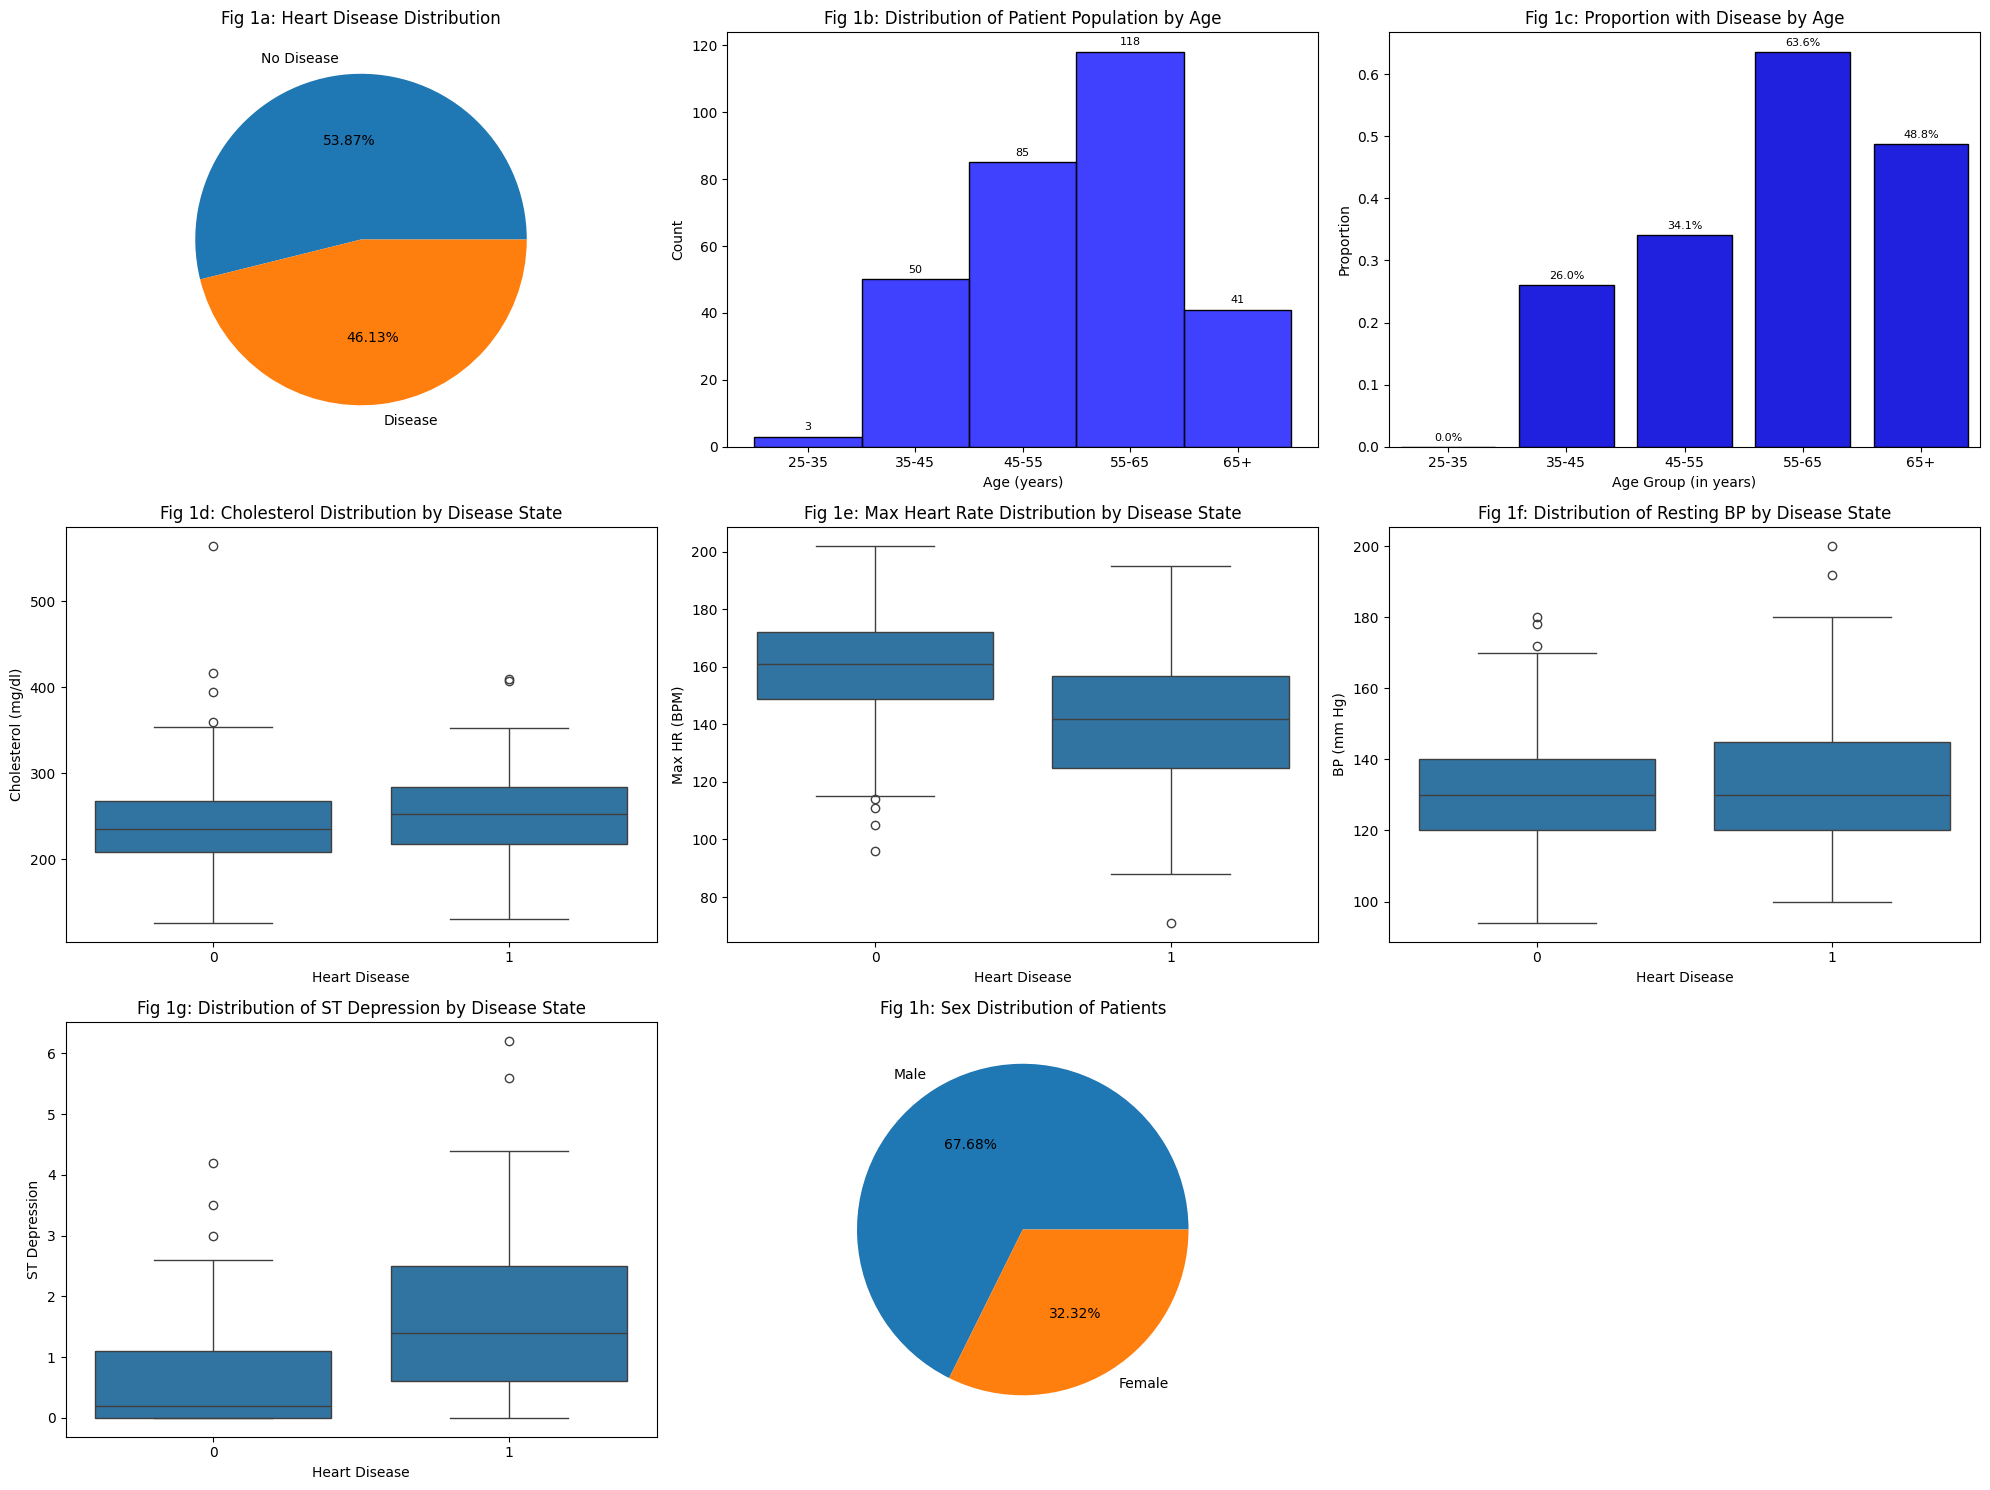

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

# make a big figure for all the plots
fig = plt.figure(figsize=(20, 15))

# row 1 - pie chart of disease
plt.subplot(3, 3, 1)
# count target as 1, or has it, or 0, does not have it
target_counts = heart_df['target'].value_counts()
plt.pie(target_counts, labels=['No Disease', 'Disease'], autopct='%0.2f%%')
plt.title('Fig 1a: Heart Disease Distribution')

# bin ages into 5 groups using age column
heart_df2 = heart_df
heart_df2['age_group'] = pd.cut(heart_df2['age'], bins=5)

# maximum age for bounding the chart
print("Maximum age of a patient in the dataset is", heart_df2['age'].max() + 1)
# bins in groups of 10: 25-35, 35-45, 55-65, and 65+ (ending at 78) with corresponding labels
bins = [25, 35, 45, 55, 65, heart_df2['age'].max()+1]
labels = ['25-35', '35-45', '45-55', '55-65', '65+']

# create a new age_group column with these bins; right means the upper values go into the bin, lower values go in one prior
heart_df2['age_group'] = pd.cut(heart_df2['age'], bins=bins, labels=labels, right=False)

# calculate proportion of patients with disease per age group
# reset.index allows heart2 to continue functioning as a dataframe
age_prop = heart_df2.groupby('age_group')['target'].mean().reset_index()
# printing columns for debugging
print(age_prop.columns)

# plot total number of patients by age using the numeric 'age' column and custom bins
plt.subplot(3,3,2)
sns.histplot(data=heart_df2, x='age_group', bins=bins, color='blue', edgecolor='black')
plt.title('Fig 1b: Distribution of Patient Population by Age')
plt.xlabel('Age (years)')
plt.ylabel('Count')
# count number of patients in each age group; sorting to make sure aligned with age bins
age_counts = heart_df2['age_group'].value_counts().sort_index()
# same method will be used to put the counts 2 above the bin
for i, v in enumerate(age_counts):
    plt.text(i, v+2, str(v), ha='center', fontsize=8)

# % with disease by age
plt.subplot(3,3,3)
sns.barplot(data=age_prop, x='age_group', y='target', color='blue', edgecolor='black')
plt.title('Fig 1c: Proportion with Disease by Age')
plt.xlabel('Age Group (in years)')
plt.ylabel('Proportion')
# % on bars for showing the proportion
for i, v in enumerate(age_prop['target']):
    percent = v*100  # convert to percent
    percent = round(percent, 1)  # round to 1 decimal
    # adding it 0.01 above the height of the proportion for easy reading
    plt.text(i, v+0.01, str(percent) + '%', ha = 'center', fontsize=8)


plt.subplot(3,3,4)
# plot boxplot showing cholesterol levels by group
# easy to see distribution differences
sns.boxplot(data=heart_df, x='target', y='chol')
plt.title('Fig 1d: Cholesterol Distribution by Disease State')
plt.xlabel('Heart Disease')
plt.ylabel('Cholesterol (mg/dl)')

# this will show maximum heart rate distribution between two groups
plt.subplot(3,3,5)
sns.boxplot(data=heart_df, x='target', y='thalach')
plt.title('Fig 1e: Max Heart Rate Distribution by Disease State')
plt.xlabel('Heart Disease')
plt.ylabel('Max HR (BPM)')

# resting bp distribution between heart disease positive and negative griups
plt.subplot(3,3,6)
sns.boxplot(data=heart_df2, x='target', y='trestbps')
plt.title('Fig 1f: Distribution of Resting BP by Disease State')
plt.xlabel('Heart Disease')
plt.ylabel('BP (mm Hg)')

# ST depression distribution between heart disease positive and negative
plt.subplot(3,3,7)
sns.boxplot(data=heart_df2, x='target', y='oldpeak')
plt.title('Fig 1g: Distribution of ST Depression by Disease State')
plt.xlabel('Heart Disease')
plt.ylabel('ST Depression')

# sex distribution pie chart
plt.subplot(3,3,8)
# count males and females; labels are set accordingly
sex_counts = heart_df['sex'].value_counts()  # assuming 1 = male, 0 = female
labels = ['Male', 'Female']
# pie chart with same formatting as the first chart I made
plt.pie(sex_counts, labels=labels, autopct='%0.2f%%')
plt.title('Fig 1h: Sex Distribution of Patients')
plt.tight_layout()
plt.show()

# list of binary/categorical features to exclude
binary_features = ['target', 'sex', 'fbs', 'exang']

# features already plotted as boxplots
already_plotted = ['chol', 'thalach', 'trestbps', 'oldpeak']

/tmp/ipython-input-502332944.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.85625' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  main_props.loc[i, 'prop'] = prop
/tmp/ipython-input-502332944.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.575' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  main_props.loc[i, 'prop'] = prop
/tmp/ipython-input-502332944.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.85625' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  main_props.loc[i, 'prop'] = prop
/tmp/ipython-input-502332944.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will ra

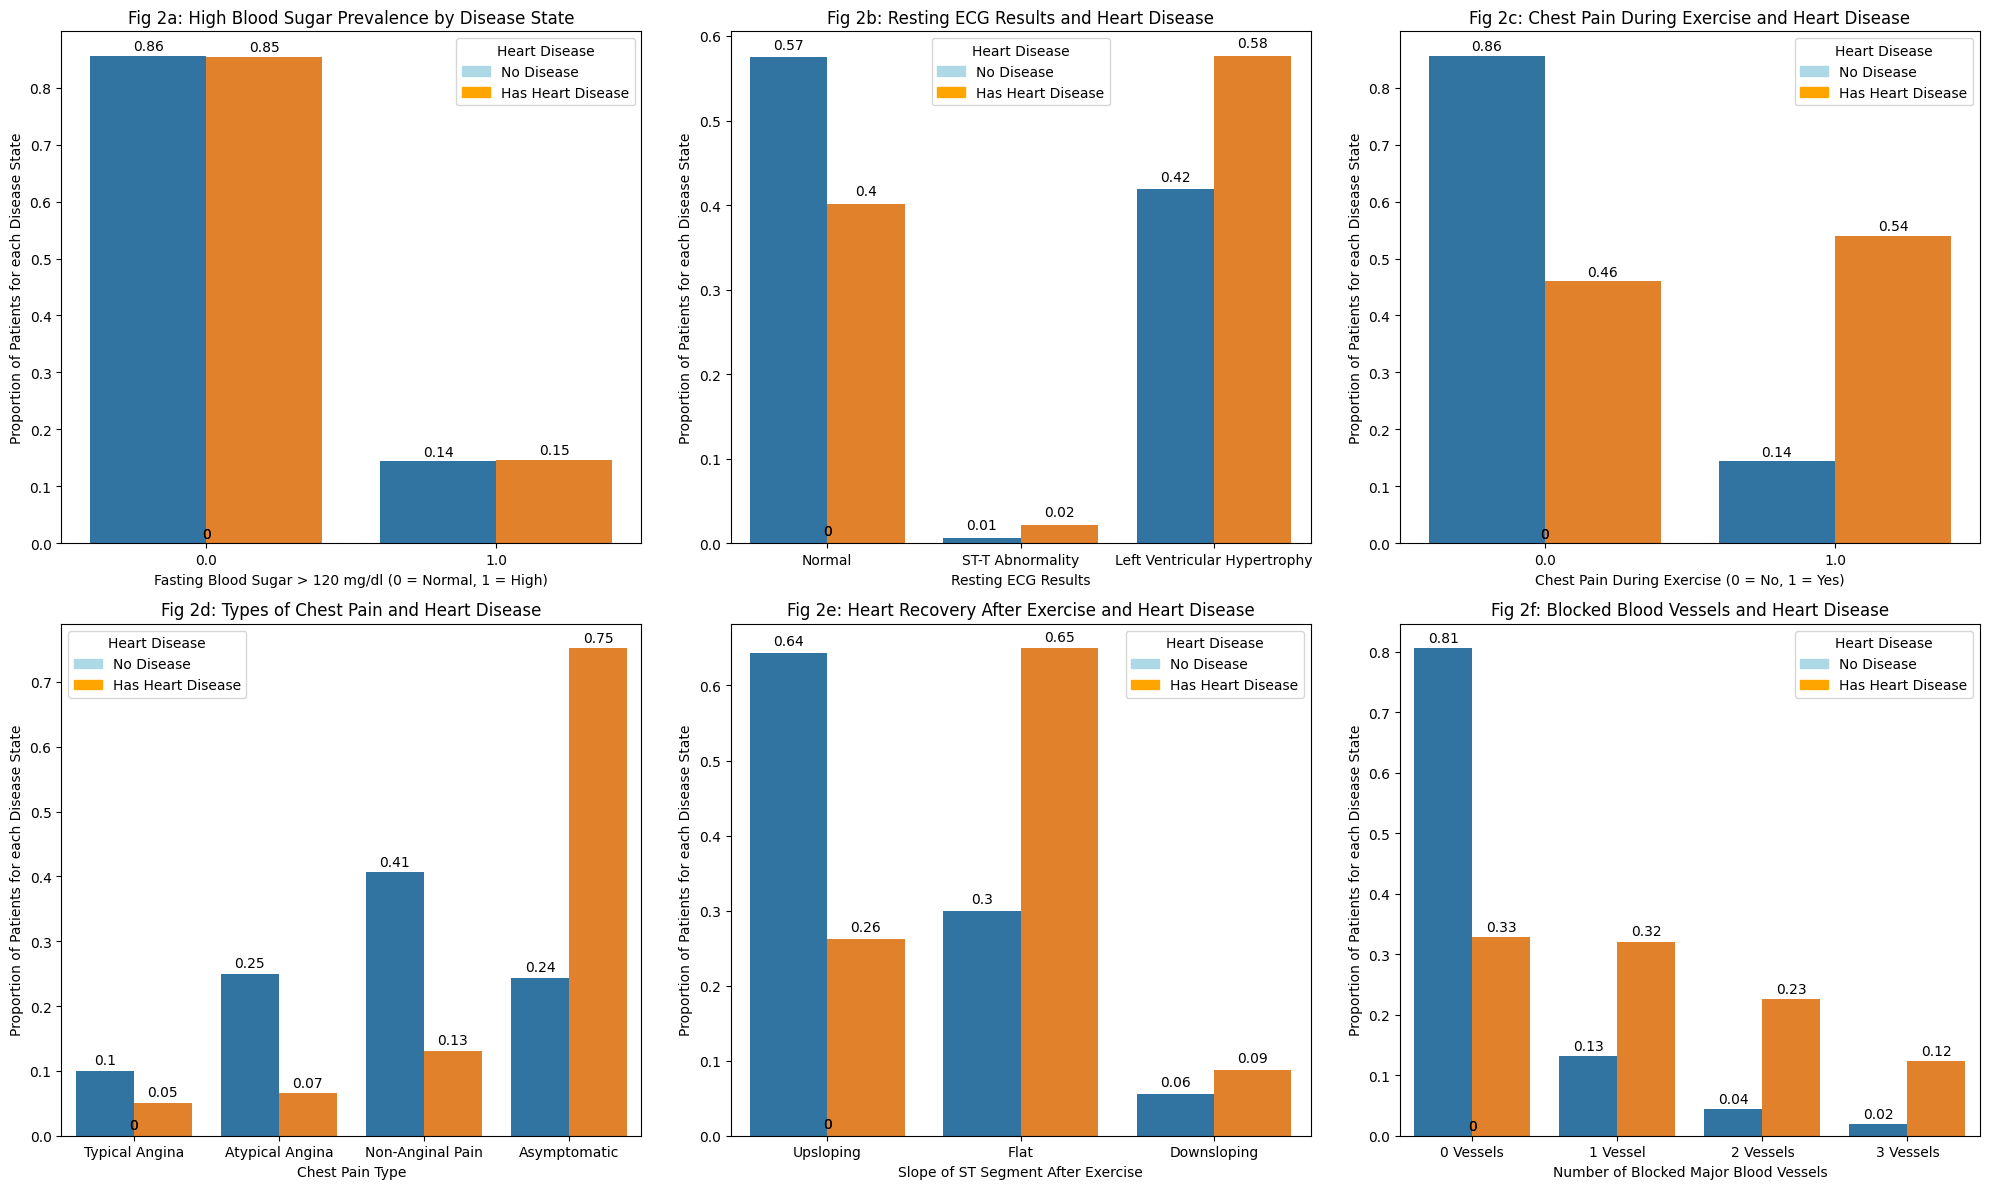

In [ ]:
import matplotlib.patches as mpatches # setting color guide for custom figuress

# count the number of people in each group to assign proportions
def count_people(df, col):
    # take a given column, i.e. a feature; and create sub-dfs containing only a given column and the single disease state
    counts = df.groupby([col, 'target']).size()
    # create a main_props dataframe with a counts column
    main_props = counts.reset_index(name='count')
    # proportions column initialized to 0
    main_props['prop'] = 0

    # for unique disease state labels (0 or 1)
    for t in main_props['target'].unique():
        # number of patients with the given disease state
        total = main_props[main_props['target'] == t]['count'].sum()
        # row indices corresponding to disease state
        indices = main_props[main_props['target'] == t].index
        for i in indices:
            # calculate proportion with the count divided by the total rows
            prop = main_props.loc[i, 'count'] / total
            main_props.loc[i, 'prop'] = prop
    return main_props

# showcase the features, title, x-axis with context, and categories if multi-class classification
# if binary, last column value is NA - no multi class classification occuring here
plot_data = [
    ('fbs', 'Fig 2a: High Blood Sugar Prevalence by Disease State', 'Fasting Blood Sugar > 120 mg/dl (0 = Normal, 1 = High)', None),
    ('restecg', 'Fig 2b: Resting ECG Results and Heart Disease', 'Resting ECG Results', ['Normal','ST-T Abnormality','Left Ventricular Hypertrophy']),
    ('exang', 'Fig 2c: Chest Pain During Exercise and Heart Disease', 'Chest Pain During Exercise (0 = No, 1 = Yes)', None),
    ('cp', 'Fig 2d: Types of Chest Pain and Heart Disease', 'Chest Pain Type', ['Typical Angina','Atypical Angina','Non-Anginal Pain','Asymptomatic']),
    ('slope', 'Fig 2e: Heart Recovery After Exercise and Heart Disease', 'Slope of ST Segment After Exercise', ['Upsloping','Flat','Downsloping']),
    ('ca', 'Fig 2f: Blocked Blood Vessels and Heart Disease', 'Number of Blocked Major Blood Vessels', ['0 Vessels','1 Vessel','2 Vessels','3 Vessels']),
    ('thal', 'Blood Flow to Heart and Heart Disease', 'Blood Flow Test Results', ['Normal Blood Flow','Fixed Defect','Reversible Defect'])
]

# create 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()  # flatten to 1D for easy indexing

# iterate through each element in the plot_data array
for idx, (col, title, xlabel, xticks_labels) in enumerate(plot_data[:6]):  # only first 6 to fit 2x3
    data = count_people(heart_df, col)
    # barplot showign proportions for the given x-axis and clinical context
    ax = sns.barplot(data=data, x=col, y='prop', hue="target", ax=axes[idx])

    # label placement above bar by height 0.01
    # patch.get_x() + patch.get_width()/2 keeps the label right in the middle of the given bar and the next bar
    # clustered columns
    for i, patch in enumerate(ax.patches):
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width()/2, height + 0.01, round(height, 2),
                ha='center', fontsize=10)

    # title and labels
    axes[idx].set_title(title)
    axes[idx].set_xlabel(xlabel)
    axes[idx].set_ylabel('Proportion of Patients for each Disease State')
    # assign labels based on xtick values
    if xticks_labels:
        axes[idx].set_xticks(range(len(xticks_labels)))
        axes[idx].set_xticklabels(xticks_labels)

    # add legend with color coding
    blue_patch = mpatches.Patch(color='lightblue', label='No Disease')
    orange_patch = mpatches.Patch(color='orange', label='Has Heart Disease')
    axes[idx].legend(title='Heart Disease', handles=[blue_patch, orange_patch])

plt.tight_layout()
plt.show()

In [ ]:
# Statistical Testing and Data Analysis
#  .describe() method provides statistics (mean, median, etc.)
print("Statistical Summary of Clinical Features:")
print(heart_df2.describe().round(2))

print("Statistical Significance Testing:")
features = heart_df2.columns.tolist()
features.remove('target')
features.remove('age_group')
alpha = 0.05 # p value threshold
num = len(features) # for correction of features; multiplying p-value by num_features, or num_tests

for f in features:
    # values for features for no_disease and disease group respectively
    no_disease = heart_df2[heart_df2['target']==0][f]
    disease = heart_df2[heart_df2['target']==1][f]
    # t_test of means between groups
    t_stat, p_val = stats.ttest_ind(no_disease, disease)

    # correction by number of hypotheses
    p_corr = p_val * num
    if p_corr > 1:
        p_corr = 1

    # using stars to denote significance
    sig = 'NS'
    if p_corr < 0.001:
        sig = '***'
    elif p_corr < 0.01:
        sig = '**'
    elif p_corr < 0.05:
        sig = '*'
    # Print mean of both groups, and results of statistical tests (pre- and post-correction with significance)
    print("\n")
    print('\nMean of no heart disease group:', round(no_disease.mean(), 2))
    print('Mean of heart disease group:', round(disease.mean(), 2))
    print(f + ": t = " + str(round(t_stat, 3)) + ", raw p = " + str(p_val) +  ", corrected p = " + str(p_corr) +  " " + sig)


Statistical Summary of Clinical Features:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  297.00  297.00  297.00    297.00  297.00  297.00   297.00   297.00   
mean    54.54    0.68    3.16    131.69  247.35    0.14     1.00   149.60   
std      9.05    0.47    0.96     17.76   52.00    0.35     0.99    22.94   
min     29.00    0.00    1.00     94.00  126.00    0.00     0.00    71.00   
25%     48.00    0.00    3.00    120.00  211.00    0.00     0.00   133.00   
50%     56.00    1.00    3.00    130.00  243.00    0.00     1.00   153.00   
75%     61.00    1.00    4.00    140.00  276.00    0.00     2.00   166.00   
max     77.00    1.00    4.00    200.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  target  
count  297.00   297.00  297.00  297.00  297.00  297.00  
mean     0.33     1.06    1.60    0.68    4.73    0.46  
std      0.47     1.17    0.62    0.94    1.94    0.50  
min      0.00     0.00    1.00    0.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset

# Neural Network Architecture inspired by literature, namely by Srivastava and Chatterjee (2025)
"""
Input layer with 13 features followed by batch normalization.
Next, a dense, hidden layer with 32 neurons, batch normalization, ReLU activation, and dropout.
Then a dense, hidden layer with 16 neurons, batch normalization, ReLU activation, and dropout.
Finally, a dense layer with 1 neuron, sigmoid activation, producing an output probability between 0 and 1.
Adapted from literature, but I changed number of neurons, dropout rate, batchnorm frequency, and input size parameters to work well with my code
"""

class HeartDiseaseNN(nn.Module):
    # Neural Network for Heart Disease Prediction inspired by "Achieving Superior Predictive Performance through Deep Neural Networks
    #for Enhanced Cardiovascular Disease Detection" (IJRPR 2025) by Srivastava and Chatterjee

    def __init__(self, input_size = 5, hidden_sizes=[32, 16], dropout_rate=0.4):
      super(HeartDiseaseNN, self).__init__()
      input_size = input_size # changing
      hidden1, hidden2 = hidden_sizes
      # dropout rate for regularization to prevent overfitting
      # tested 0.3 and found validation loss grew with time
      # also tested 128, 64, and 32 and found validation loss grw over time
      dropout_rate = 0.4

      # Input batch normalization, from literature
      self.input_bn = nn.BatchNorm1d(input_size)

      # two hidden layers; both followed by batch normalization and relu activation
      # dropout helps prevent overfitting
      # Relu and normalization from literature
      self.fc1 = nn.Linear(input_size, hidden1)
      self.bn1 = nn.BatchNorm1d(hidden1)
      self.act1 = nn.ReLU()
      self.drop1 = nn.Dropout(dropout_rate)

      self.fc2 = nn.Linear(hidden1, hidden2)
      self.bn2 = nn.BatchNorm1d(hidden2)
      self.act2 = nn.ReLU()
      self.drop2 = nn.Dropout(dropout_rate)

      # takes final 16 neurons and outputs a single neuron
      # sigmoid function used to predict probability of heart_disease_positive, between 0 and 1
      self.output = nn.Linear(hidden2, 1)
      self.output_activation = nn.Sigmoid()

    def forward(self, x):
      # Input normalization
      x = self.input_bn(x)

      # Process through hidden layers (2 of them)
      # Hidden layer 1
      x = self.fc1(x)
      x = self.bn1(x)
      x = self.act1(x)
      x = self.drop1(x)

      # Hidden layer 2
      x = self.fc2(x)
      x = self.bn2(x)
      x = self.act2(x)
      x = self.drop2(x)

      # Final output using sigmoid function
      # output is a probability that will be used to make decisions regarding disease status
      x = self.output(x)
      x = self.output_activation(x)

      return x

In [ ]:
class HeartDataset(Dataset):
    def __init__(self, features, targets):
        # features and targets; flattened to 1 row for labels/targets
        self.features = torch.FloatTensor(features)
        self.targets = torch.FloatTensor(targets).unsqueeze(1)

    def __len__(self):
        return len(self.features)

    # return the features and target pair; proper pytorch dataset class referenced from: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

In [ ]:
print(heart_df.head())
# X = all features except target, y = target column
X = heart_df.drop('target', axis=1)
X = X.drop("age_group", axis = 1) # extra parameter from before for visualization
y = heart_df['target']

# split X and y into train+val and test first
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# split train+val into train and validation sets
# so it's about 65% train, 15% validation, 20% test
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1875, random_state=42, stratify=y_train_val)

# scale features as done in previous homeworks
scaler = StandardScaler()
# fit scaler on train and transform it as well
X_train_scaled = scaler.fit_transform(X_train)
# use learned transform parameters to transform validation and test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# size check due to errors
print("Number of training samples:", X_train_scaled.shape[0])
print("Number of validation samples:", X_val_scaled.shape[0])
print("Number of test samples:", X_test_scaled.shape[0])

# new HeartDataset objects using scaled x and y paired data
train_dataset = HeartDataset(X_train_scaled, y_train.values)
val_dataset = HeartDataset(X_val_scaled, y_val.values)
test_dataset = HeartDataset(X_test_scaled, y_test.values)

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target age_group  
0    3.0  0.0   6.0       0     55-65  
1    2.0  3.0   3.0       1       65+  
2    2.0  2.0   7.0       1       65+  
3    3.0  0.0   3.0       0     35-45  
4    1.0  0.0   3.0       0     35-45  
Number of training samples: 192
Number of validation samples: 45
Number of test samples: 60


Input features: 13
Epoch 10 of 50
Train Loss: 0.448934879899025 Val Loss: 0.4740995268026988
Train Acc: 85.41666666666667 Val Acc: 80.0
Epoch 20 of 50
Train Loss: 0.3567286550998688 Val Loss: 0.4627041816711426
Train Acc: 85.41666666666667 Val Acc: 84.44444444444444
Early stopping triggered at epoch 24


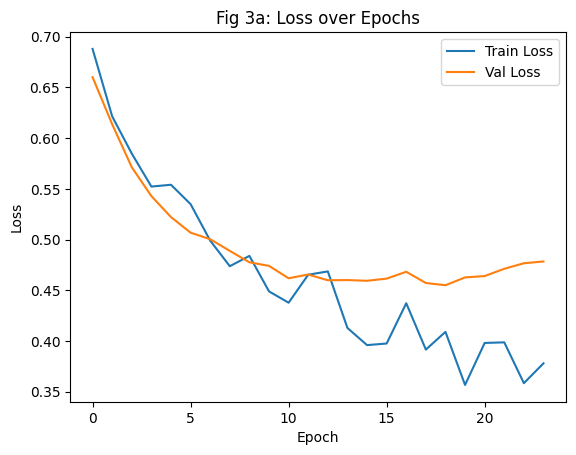

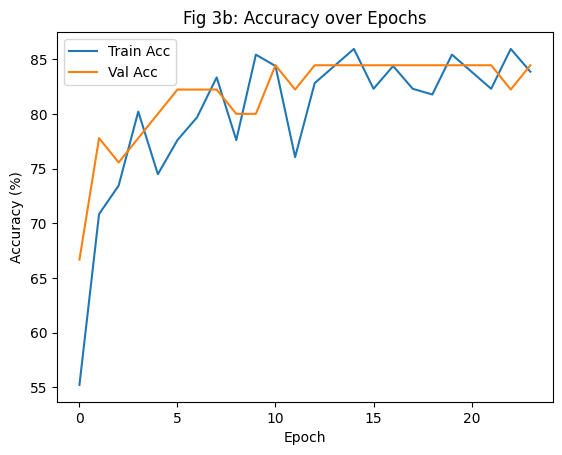

In [ ]:
# shuffle train but not validation/test; batch the data as done prior; train loader the next step to loading tensors with PyTorch
batch_size = 20  # samples per batch; set to avoid having 1 sample per batch in last sample, and constrained by limited sample size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

input_size = X_train_scaled.shape[1]  # number of features
# initialize model using input_size, or number of features
model = HeartDiseaseNN(input_size=input_size, hidden_sizes=[64, 32], dropout_rate=0.4)

# Loss and optimizer as done in class
criterion = nn.BCELoss()  # Binary Cross Entropy as shown before
# learning rate set to 0.001 from previous assignment
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Input features:", input_size)

num_epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Early stopping class for PyTorch; reference: https://pythonguides.com/pytorch-early-stopping/

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience        # number of epochs to wait
        self.min_delta = min_delta      # minimum improvement to count
        self.counter = 0    # count epochs as we fall under minimum improvement
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta: # minimum difference between best loss and validation loss at the moment defines stoppage
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True  # stop early if counter exceeds patience
        else:
            self.best_loss = val_loss
            self.counter = 0

# initialize early stopping
early_stopping = EarlyStopping(patience=5, min_delta=0.001)
best_model_state = None

# Training method: The model will train batch by batch epoch by epoch. For each epoch,
# the code will compute a training (what it's trained on) and validation (unseen until validation) accuracy on all batches, and further detect if the validation
# loss/accuracy is not improving to a minimum threshold. If the validation accuracy does not improve to this threshold, the training
# will stop at the given epoch. This is application of EarlyStopping (adapted from TensorFlow/Keras)
for epoch in range(num_epochs):
    model.train()
    # zero loss and evaluation metrics at the beginning
    train_loss_epoch = 0
    train_correct = 0
    train_total = 0

    # for training_loader, reset gradients, move forward, and backpropagate
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        # compute BCE loss
        loss = criterion(outputs, batch_y)
        # backpropagate to compute new model weights
        loss.backward()
        optimizer.step()

        # sum loss
        train_loss_epoch += loss.item()

        # predictions (1 or 0)
        preds = []
        for o in outputs:
            # threshold set to 0.5
            if o > 0.5:
                preds.append(1.0)
            else:
                preds.append(0.0)

        # make preds a tensor
        preds = torch.tensor(preds)

        # count number of samples and number correct within that for training (likely higher than validation)
        num_samples = 0
        for i in batch_y:
            num_samples += 1
        train_total += num_samples

        num_correct = 0
        for i in range(num_samples):
            if preds[i] == batch_y[i]:
                num_correct += 1
        train_correct += num_correct

    # Validation performance to detect overfitting or any errors
    model.eval()  # model in evaluation mode
    # track losses
    val_loss_epoch = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # no gradients needed for validation
        for batch_X, batch_y in val_loader:
            # perform same procedure as did for training; compute outputs, loss, append to existing loss
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss_epoch += loss.item()

            # predictions (1 or 0)
            preds = []
            for o in outputs:
                # threshold set to 0.5
                if o > 0.5:
                    preds.append(1.0)
                else:
                    preds.append(0.0)

            # make preds a tensor
            preds = torch.tensor(preds)

            # keeping track of samples validated on and corresponding accuracy here
            # count number of samples in this batch
            num_samples = 0
            for i in batch_y:
                num_samples += 1
            val_total += num_samples  # add to val_total, not train_total

            # count number of correct predictions
            num_correct = 0
            for i in range(num_samples):
                if preds[i] == batch_y[i]:
                    num_correct += 1
            val_correct += num_correct  # add to val_correct, not train_correct

    # calculate metrics
    train_loss = train_loss_epoch / len(train_loader)
    val_loss = val_loss_epoch / len(val_loader)
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total

    # save metrics for plotting later
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # if the best_model_state hasn't been achieved or we have not reached early stopping conditions, save model parameters
    if best_model_state is None or val_loss < early_stopping.best_loss:
        best_model_state = model.state_dict().copy()

    # check early stopping condition; if we have not improved on loss by min_delta after patience number of epochs, we break
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered at epoch", str(epoch+1))
        break

    # print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print("Epoch", epoch+1, "of", num_epochs)
        print("Train Loss:", train_loss, "Val Loss:", val_loss)
        print("Train Acc:", train_acc, "Val Acc:", val_acc)

# restore best model
model.load_state_dict(best_model_state)

# Plot trainig loss over time; train and validation
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Fig 3a: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Accuracy over time; two groups: train and validation
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.title('Fig 3b: Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

PERFORMANCE ON TESTING DATA
accuracy   : 0.8833333333333333
precision  : 0.92
recall: 0.8214285714285714
f1score: 0.8679245283018868
aucroc  0.9553571428571428
                  precision    recall  f1-score   support

No Heart Disease       0.86      0.94      0.90        32
         Disease       0.92      0.82      0.87        28

        accuracy                           0.88        60
       macro avg       0.89      0.88      0.88        60
    weighted avg       0.89      0.88      0.88        60



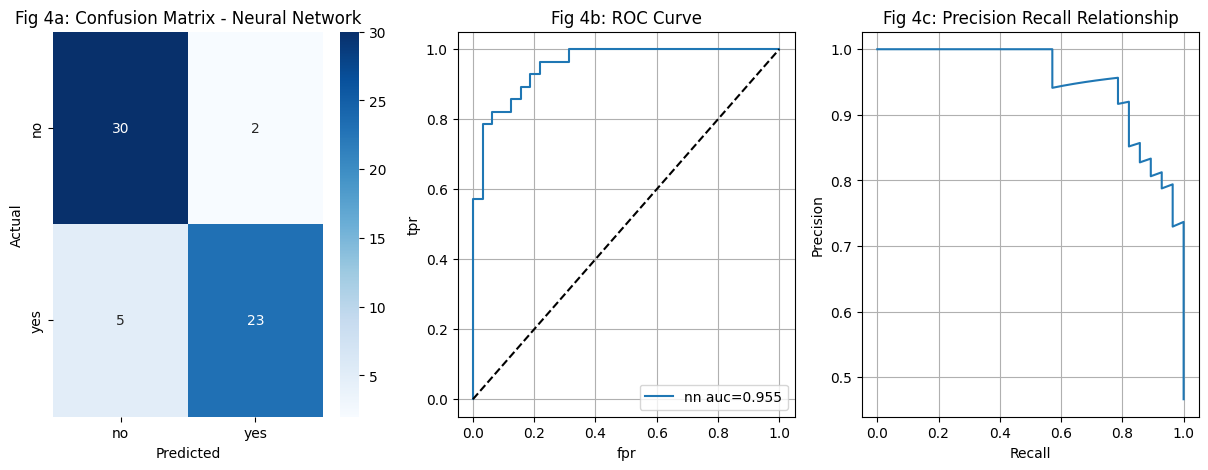

In [ ]:
# Model Evaluation
def evaluate_model(model, test_loader):
    # eval mode to prevent any kind of learning from going on
    model.eval()
    all_predictions = []
    all_probabilities = []
    all_targets = []

    # also pause gradient so no learning occurs
    with torch.no_grad():
        # load batch features and targets to predict on from model
        for batch_features, batch_targets in test_loader:
            # predict output probabilities and convert to numpy
            outputs = model(batch_features)
            probabilities = outputs.numpy()
            # render each output a binary 1 or 0
            predictions = (outputs > 0.5).float().numpy()

            # append to probabilities, predictions, and expectations or targets
            all_probabilities.extend(probabilities)
            all_predictions.extend(predictions)
            all_targets.extend(batch_targets.numpy())

    # return a series of arrays containing preds, probs, and targets
    return np.array(all_predictions), np.array(all_probabilities), np.array(all_targets)

# Get predictions
y_pred, y_proba, y_true = evaluate_model(model, test_loader)

# Compute accuracy, precision, recall, f1_score, and auc
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc_roc = roc_auc_score(y_true, y_proba)

print("PERFORMANCE ON TESTING DATA")
print("accuracy   :", accuracy)
print("precision  :", precision)
print("recall:", recall)
print("f1score:", f1)
print("aucroc ", auc_roc)

# classification report gives details about classification accuracies, etc. with desired labels
print(classification_report(y_true, y_pred, target_names=['No Heart Disease', 'Disease']))

# Figures in one row; confusion matric, ROC curve, precision-recall curve
fig = plt.figure(figsize=(20, 5))

plt.subplot(1,4,1)
cm = confusion_matrix(y_true,y_pred)
# confusion matrix with annotations, blue colors used for labeling, xtick and ytick set to no or yes depending on presence
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['no','yes'],yticklabels=['no','yes'])
plt.title('Fig 4a: Confusion Matrix - Neural Network')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# ROC curve
plt.subplot(1,4,2)
# produce roc curve and fpr, tpr; plot the two against one another for roc curve
fpr,tpr,_ = roc_curve(y_true,y_proba)
plt.plot(fpr,tpr, label='nn auc=' + str(round(auc_roc,3)))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('Fig 4b: ROC Curve')
plt.legend()
plt.grid(True)

# Precision recall
plt.subplot(1,4,3)
prec,rec,_ = precision_recall_curve(y_true,y_proba)
plt.plot(rec,prec)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Fig 4c: Precision Recall Relationship')
plt.grid(True)

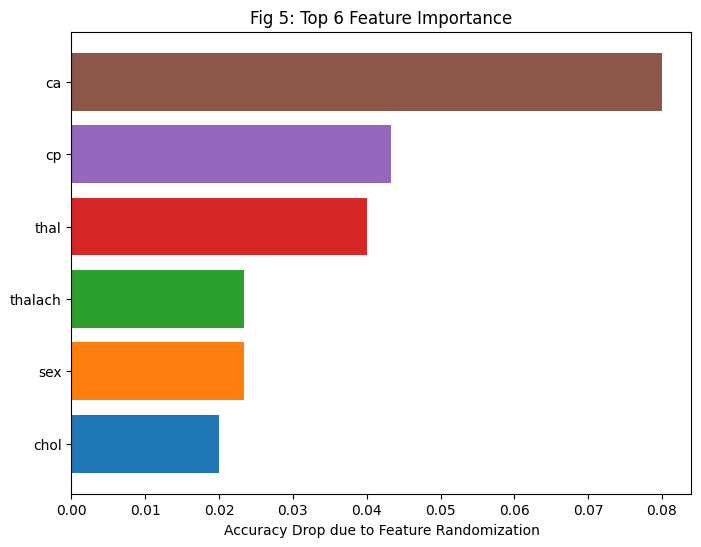


Top 5 features by importance
ca : 0.08
cp : 0.0433
thal : 0.04
thalach : 0.0233
sex : 0.0233
chol : 0.02

Features reducing accuracy, with their mean accuracy reduction score following randomization
fbs : -0.0033


In [ ]:
# feature list
feat_names = X.columns.tolist()

# score array to store importance
scores = {}

# baseline accuracy on the "re-torched" X test dataset
preds0 = model(torch.FloatTensor(X_test_scaled))
# convert probabilities to 0 or 1 binary and compute accuracy score using y_test
preds0 = (preds0.detach().numpy() > 0.5).astype(int)
base_acc = accuracy_score(y_test, preds0)

# loop over features
for f in range(len(feat_names)):
    score_list = []
    # repeat 5 times per feature; average loss of accuracy over those 5 iterations
    for r in range(5):
        # new version of the input features
        Xp = X_test_scaled.copy()
        # shuffle column f; given feature; randomly
        # each column corresponds to a feature; each row corresponds to a datapoint
        col = Xp[:, f]
        # new column to replace old column (erasing patterns)
        np.random.shuffle(col)
        Xp[:, f] = col

        # predict on shuffled dataset and evaluate accuracy as before
        preds = model(torch.FloatTensor(Xp))
        preds = (preds.detach().numpy() > 0.5).astype(int)
        acc = accuracy_score(y_test, preds)
        # difference in accuracy between baseline and feature_pattern_elimination
        score_list.append(base_acc - acc)

    # average drop per feature saved
    avg = sum(score_list)/len(score_list)
    scores[feat_names[f]] = avg
sorted_feats = sorted(scores.items(), key=lambda x: x[1], reverse=True)  # biggest drop first
top_feats = sorted_feats[:6]  # take top 6

# simple horizontal bar plot for top 6 only
plt.figure(figsize=(8,6))
for k, v in reversed(top_feats):
    plt.barh(k, v)
plt.title('Fig 5: Top 6 Feature Importance')
plt.xlabel('Accuracy Drop due to Feature Randomization')
plt.show()

# Print top features by importance and then features on average contributing negatively to model performance
print("\nTop 5 features by importance")
for i in top_feats:
    print(i[0], ":", round(i[1], 4))

print("\nFeatures reducing accuracy, with their mean accuracy reduction score following randomization")
for i in sorted_feats:
  if i[1] < 0:
    print(i[0], ":", round(i[1], 4))

In [ ]:
# interpreting best features; what they mean using feature_context from before
for i in range(0,5):
    feature_name = top_feats[i][0]
    importance_score = round(top_feats[i][1], 4)  # use top_feats directly for positive importance
    description = feature_descriptions.get(feature_name, "Unknown feature")
    print(feature_name, " (importance:", importance_score,")")
    print("What it is:", description)
    print()


ca  (importance: 0.08 )
What it is: Number of major vessels (0-3) colored by fluoroscopy; Essentially, higher numbers usually indicate more extensive coronary artery involvement, which can suggest a higher risk of heart disease.

cp  (importance: 0.0433 )
What it is: Chest pain type (0: typical angina, 1: atypical angina, 2: non-anginal pain, 3: asymptomatic)

thal  (importance: 0.04 )
What it is: Thalassemia (3 = normal; 6 = fixed defect; 7 = reversible defect)

thalach  (importance: 0.0233 )
What it is: Maximum heart rate achieved

sex  (importance: 0.0233 )
What it is: Sex (1 = male; 0 = female)



Comparison of Neural Network with Other Models
Training Logistic Regression
Training Random Forest
Training SVM
                     accuracy  precision  recall      f1  auc_roc
Neural Network         0.8833     0.9200  0.8214  0.8679   0.9554
Logistic Regression    0.8333     0.8462  0.7857  0.8148   0.9520
Random Forest          0.8500     0.8800  0.7857  0.8302   0.9509
SVM                    0.8667     0.8846  0.8214  0.8519   0.9587


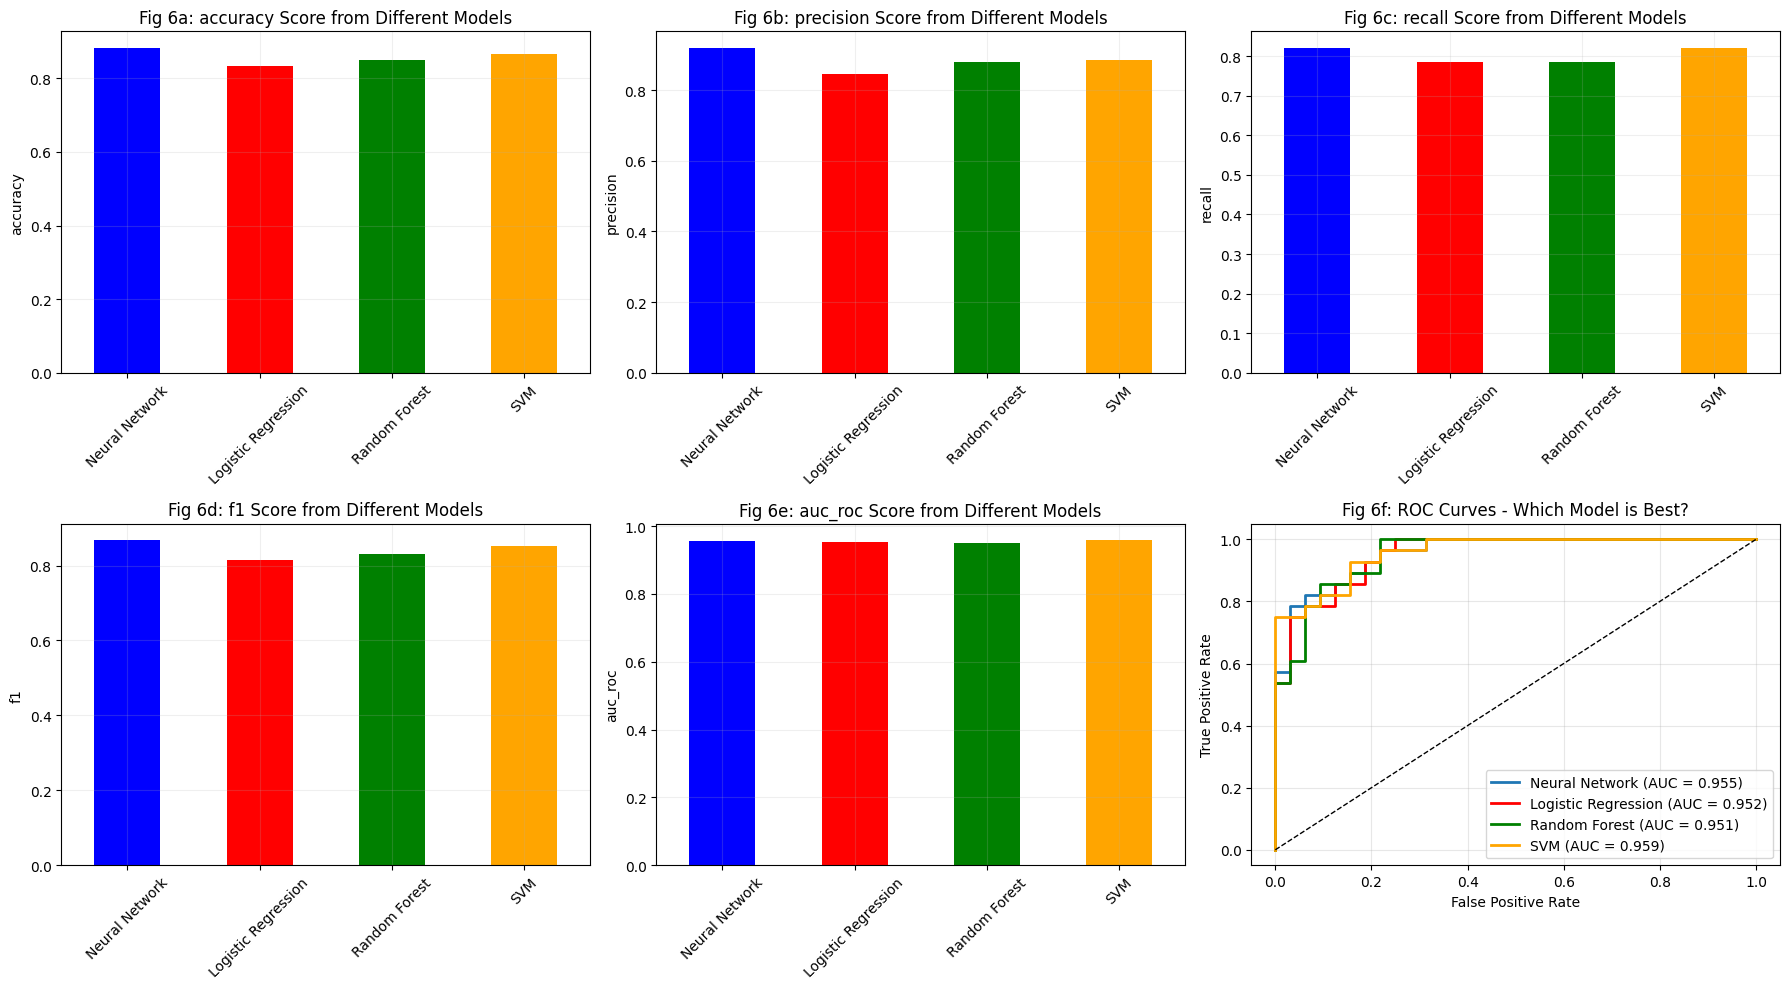

Best accuracy  Neural Network  0.8833333333333333
Best precision  Neural Network  0.92
Best recall  Neural Network  0.8214285714285714
Best f1  Neural Network  0.8679245283018868
Best auc_roc  SVM  0.9587053571428572


In [ ]:
# Machine Learning Models to compare Neural Network with
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Initializing other machine learning models
# dictionary stores name as key and model as value
other_models = {'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),'SVM': SVC(random_state=42, probability=True)}
all_results = {}
print("Comparison of Neural Network with Other Models")

# array to store results from models; first one is already made and is Neural Network
all_results['Neural Network'] = {'accuracy': accuracy, 'precision': precision, 'recall': recall,'f1': f1, 'auc_roc': auc_roc
}

# Test each model
for model_name, model in other_models.items():
    print("Training", model_name)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Get probability predictions on the test_scaled data, probability of heart_disease
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        break
    # append results for the given model name
    all_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc_roc': roc_auc_score(y_test, y_proba)
    }

# Make a table to compare results between all four models
results_table = pd.DataFrame(all_results).T
print(results_table.round(4))
# Make some plots to compare
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']

# 2 x 3 plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot each metric
for i, metric in enumerate(metrics):
    results_table[metric].plot(kind='bar', ax=axes[i], color=['blue', 'red', 'green', 'orange'])
    axes[i].set_title('Fig 6' + chr(97+i) + ': ' + metric + " Score from Different Models")
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha = 0.2)

# Neural network ROC curve first
axes[5].plot(fpr, tpr, linewidth=2)
legend_labels = ['Neural Network (AUC = ' + str(round(auc_roc, 3)) + ')']
axes[5].legend(['Neural Network (AUC = ' + str(round(auc_roc, 3)) + ')'])
colors = ['red', 'green', 'orange']
i = 0
for name in other_models:
    model = other_models[name]
    if hasattr(model, 'predict_proba'):
        # get probabilities from other models; second column is probability of a positive disease state
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        fpr_other, tpr_other, _ = roc_curve(y_test, y_proba)
        auc_other = roc_auc_score(y_test, y_proba)

        # Plot ROC curve
        axes[5].plot(fpr_other, tpr_other, linewidth=2, color=colors[i])

        legend_labels.append(name + ' (AUC = ' + str(round(auc_other, 3)) + ')')

        i += 1

# Add the random guess line
axes[5].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess ROC Curve')
axes[5].set_xlabel('False Positive Rate')
axes[5].set_ylabel('True Positive Rate')
axes[5].set_title('Fig 6f: ROC Curves - Which Model is Best?')
axes[5].legend(legend_labels)
axes[5].grid(True, alpha=0.3)


# Make everything fit nicely
plt.tight_layout()
plt.show()
# Find best model for each metric
for metric in metrics:
    best_model = results_table[metric].idxmax()
    best_score = results_table[metric].max()
    print("Best", metric, "", best_model, "", best_score)

Overall, SVM (basic binary classification) does overperform CNN. This is likely due to the small dataset size, the need for binary classification, and SVM ability to work with relatively low-dimensional data

Analysis of Risk by Age and Actual Status in Test Dataset (n = 60)
Patients in each risk group
risk_group
Low Risk       29
High Risk      20
Medium Risk    11
Name: count, dtype: int64


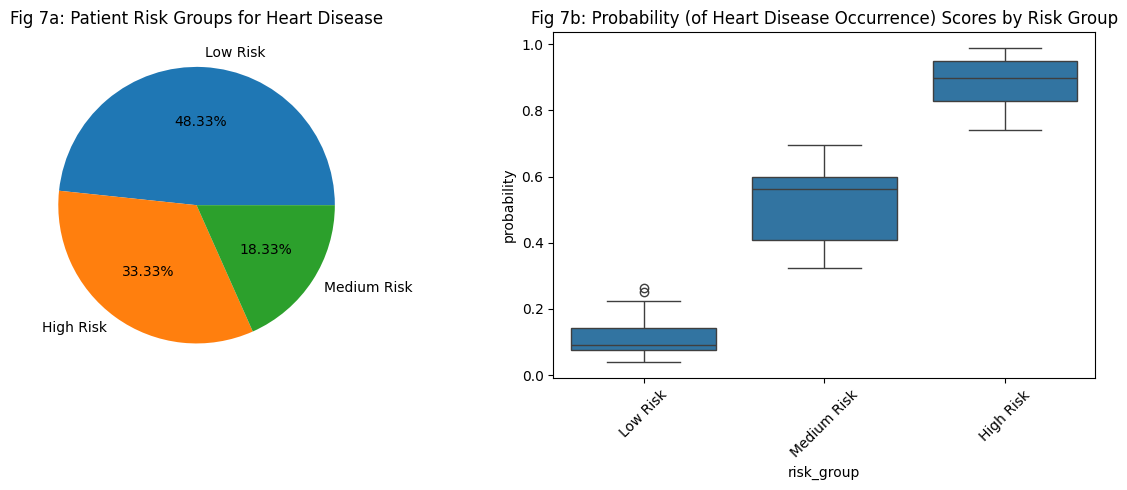

Low Risk : 2 out of 29 patients actually have heart disease
Medium Risk : 6 out of 11 patients actually have heart disease
High Risk : 20 out of 20 patients actually have heart disease

Age group: 25-35

Age group: 35-45
Low Risk : 0 out of 7
Medium Risk : 2 out of 4
High Risk : 2 out of 2

Age group: 45-55
Low Risk : 0 out of 4
Medium Risk : 0 out of 2
High Risk : 8 out of 8

Age group: 55-65
Low Risk : 2 out of 14
Medium Risk : 2 out of 3
High Risk : 8 out of 8

Age group: 65+
Low Risk : 0 out of 4
Medium Risk : 2 out of 2
High Risk : 2 out of 2


In [ ]:
print("Analysis of Risk by Age and Actual Status in Test Dataset (n = 60)")
# Put patients into risk groups by probability predicted by neural network
# Under 30% value for p, do low risk; 30-70%, medium risk; 70%+ is high risk
# Always better to overpredict heart disease
def make_risk_groups(probs):
    risk_groups = []
    for p in probs:
        if p < 0.3:
            risk_groups.append('Low Risk')
        elif p < 0.7:
            risk_groups.append('Medium Risk')
        else:
            risk_groups.append('High Risk')
    return risk_groups

risk_groups = make_risk_groups(y_proba.flatten())
# ravel takes the risk groups above and will ensure 1D array; used to unravel confusion matrices, etc.
y_true = np.ravel(y_true)
y_proba = np.ravel(y_proba)
risk_groups = np.ravel(risk_groups)
risk_table = pd.DataFrame({'actual': y_true,'probability': y_proba, 'risk_group': risk_groups})

# Add age groups, consistent from earlier code
bins = [25, 35, 45, 55, 65, 100]
labels = ['25-35', '35-45', '45-55', '55-65', '65+']
#Cut dataframe into bins; consistent with first part of the code doing age-related binning
risk_table['age_group'] = pd.cut(heart_df['age'], bins=bins, labels=labels, right=False)

print("Patients in each risk group")
print(risk_table['risk_group'].value_counts())

plt.figure(figsize=(12, 5))

# Pie chart showing patient risk groups as a proportion of all patients
plt.subplot(1, 2, 1)
counts = risk_table['risk_group'].value_counts()
plt.pie(counts.values, labels=counts.index, autopct='%0.2f%%')
plt.title('Fig 7a: Patient Risk Groups for Heart Disease')

# Box plot showing risk group and corresponding predicted probability of heart disease
plt.subplot(1, 2, 2)
sns.boxplot(data=risk_table, x='risk_group', y='probability', order=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Fig 7b: Probability (of Heart Disease Occurrence) Scores by Risk Group')
# Rotation feature allows all x labels to appear next to one another
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Count disease cases for each risk group
for group in ['Low Risk', 'Medium Risk', 'High Risk']:
    data = risk_table[risk_table['risk_group'] == group]
    total = len(data)
    # Count patients from each risk that are actually sick with heart disease
    sick = data['actual'].sum()
    print(group, ":", int(sick), "out of", int(total), "patients actually have heart disease")

# Count by age group
for age in labels:
    data_age = risk_table[risk_table['age_group'] == age]
    print("\nAge group:", age)
    for group in ['Low Risk', 'Medium Risk', 'High Risk']:
        d = data_age[data_age['risk_group'] == group]
        total = len(d)
        if total > 0:
            # sum across age group
            sick = d['actual'].sum()
            print(group, ":", int(sick), "out of", int(total))

REFERENCES

### Data Source
1. **UCI Machine Learning Repository - Heart Disease Dataset**
   - Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease
   - Citation: Detrano, R. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64, 304-310.

### Methodological References

1. **Neural Network Architectures in Biomedical Applications**
 Srivastava, Prof. (Dr.) N., & Chatterjee, P. (2025). Achieving Superior Predictive Performance through Deep Neural Networks for Enhanced Cardiovascular Disease Detection. International Journal of Research Publication and Reviews, 6(6), 5964–5968. https://doi.org/10.55248/gengpi.6.0625.21113

2. **PyTorch Methods, EarlyStop Sourcing, etc.**
Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., Killeen, T., Lin, Z., Gimelshein, N., Antiga, L., Desmaison, A., Köpf, A., Yang, E., DeVito, Z., Raison, M., Tejani, A., Chilamkurthy, S., Steiner, B., Fang, L., & Bai, J. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library. ArXiv.org. https://arxiv.org/abs/1912.01703


## Library References

Matplotlib  
Hunter, J. D. (2007). "Matplotlib: A 2D Graphics Environment."  
Computing in Science & Engineering, 9(3), 90–95.  
Official Documentation: https://matplotlib.org/stable/contents.html

Seaborn  
Used for statistical visualization.  
Official Documentation: https://seaborn.pydata.org/

Pandas  
Used for data handling and preprocessing.  
Official Documentation: https://pandas.pydata.org/docs/





